In [1]:
# ============================================
# 4. RNN 실습
# 목표:
# - 순차 데이터 분류
# - RNN(LSTM) 모델 학습
# - 학습 결과 저장
# - 저장된 모델결과 불러오기
# - 신규 시퀀스 예측
# - 학습결과 및 예측결과 시각화
# ============================================

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 시드 고정
np.random.seed(42)
tf.random.set_seed(42)


In [7]:
# ============================================
# 1. 데이터 생성
# ============================================

# 샘플 수 정의
n_samples = 1500

# 시퀀스 길이 
seq_len = 50

# 클래스 수 정의
n_classes = 3

# 빈리스트 생성
X = []
y = []

# 클래스 별 시퀀스 생성
for i in range(n_samples):
    # 시간축 생성
    t = np.linspace(0, 2 * np.pi, seq_len)

    # 클래스를 랜덤하게 선택
    label = np.random.randint(0,3)

    #클래스 0이면 sine 패턴을 생성
    if label == 0:
        seq = np.sin(t) + np.random.normal(0,0.1,seq_len)

    # 클래스 1이면 cosine 패턴을 생성
    elif label == 1:
        seq = np.cos(t) + np.random.normal(0, 0.1, seq_len)

    # 클래스 2이면 증가 추세 패턴을 생성
    else:
        seq = np.linspace(-1, 1, seq_len) + np.random.normal(0,0.1,seq_len)

    # 시퀀스 데이터 추가
    X.append(seq)
    # 라벨도 추가
    y.append(label)

# numpy 배열로 변환
X = np.array(X)
y = np.array(y)

# RNN 입력 형태인 (샘플 수, 시퀀스 길이, 특성 수) 로 reshape 필요
X = X.reshape(-1, seq_len, 1)

In [9]:
y

array([2, 0, 0, ..., 2, 0, 0], shape=(1500,))

In [10]:
# ============================================
# 2. 데이터 분리
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# ============================================
# 3. 모델 정의
# ============================================

model = Sequential()

# 첫 번째 LSTM 층을 추가
model.add(LSTM(64, input_shape=(seq_len, 1), return_sequences=False))
# 드롭아웃을 추가
model.add(Dropout(0.2))

# 완전연결층 추가
model.add(Dense(32, activation='relu'))

# 출력층 추가
model.add(Dense(n_classes, activation='softmax'))

D:\anaconda3\envs\ai\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
# ============================================
# 4. 모델 컴파일 정의
# ============================================
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# 학습 조기 종료 설정
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience= 5,
    restore_best_weights = True
)

In [16]:
# ============================================
# 5. 모델 학습
# ============================================
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7719 - loss: 0.6804 - val_accuracy: 1.0000 - val_loss: 0.1761
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0507 - val_accuracy: 1.0000 - val_loss: 0.0076
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 9.3730e-04
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 6.0454e-04
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 8.9121e-04 - val_accuracy: 1.0000 - val_loss: 4.2627e-04
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 6.2408e-04 - val_accuracy: 1.0000 - val_loss: 3.1192e-04
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 4.7117e-0

In [17]:
# ============================================
# 6. 성능 평가
# ============================================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

# 결과 출력
print("테스트 손실: ", test_loss)
print("테스트 정확도: ", test_acc)

테스트 손실:  1.7151285646832548e-05
테스트 정확도:  1.0


In [18]:
# ============================================
# 7. 예측/확률 계산
# ============================================

# 예측 확률 계산
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산
y_pred = np.argmax(y_prob, axis=1)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [19]:
# ============================================
# 8. 학습 결과 저장
# ============================================

# 저장
model.save('./results/RNN_LSTM_Model.h5')

# 읽어오기
loaded_model = tf.keras.models.load_model('./results/RNN_LSTM_Model.h5')

In [20]:
# ============================================
# 9. 신규 데이터 예측
# ============================================

# 신규 5개 패턴을 사용
new_seq = X_test[:5]

# 신규 시퀀스를 예측
new_prob = loaded_model.predict(new_seq)

# 최종 클랙스를 계산
new_pred = np.argmax(new_prob, axis=1)

# 예측결과 출력
for i in range(len(new_seq)):
    print(f"{i+1}번 시퀀스 - 예측클래스: {new_pred[i]}, 확률분포: {new_prob[i]}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1번 시퀀스 - 예측클래스: 2, 확률분포: [1.2589034e-06 1.5670419e-05 9.9998307e-01]
2번 시퀀스 - 예측클래스: 2, 확률분포: [1.3343205e-06 1.6092545e-05 9.9998260e-01]
3번 시퀀스 - 예측클래스: 0, 확률분포: [9.9998116e-01 9.6322319e-06 9.2339869e-06]
4번 시퀀스 - 예측클래스: 0, 확률분포: [9.9998057e-01 9.5197611e-06 9.8396431e-06]
5번 시퀀스 - 예측클래스: 2, 확률분포: [1.2481826e-06 1.5559703e-05 9.9998319e-01]


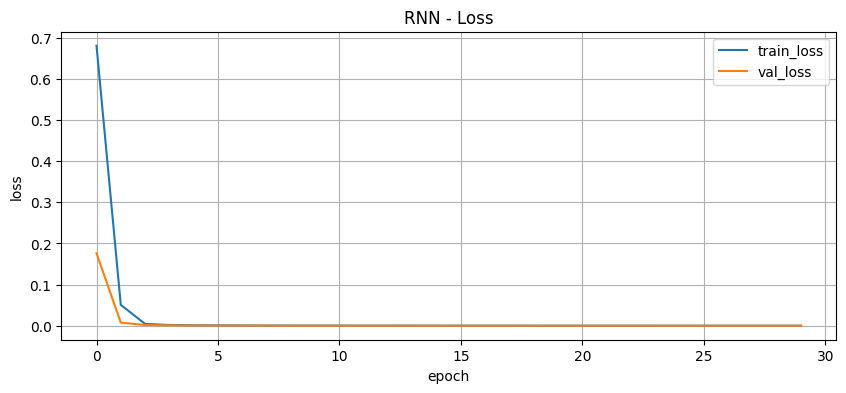

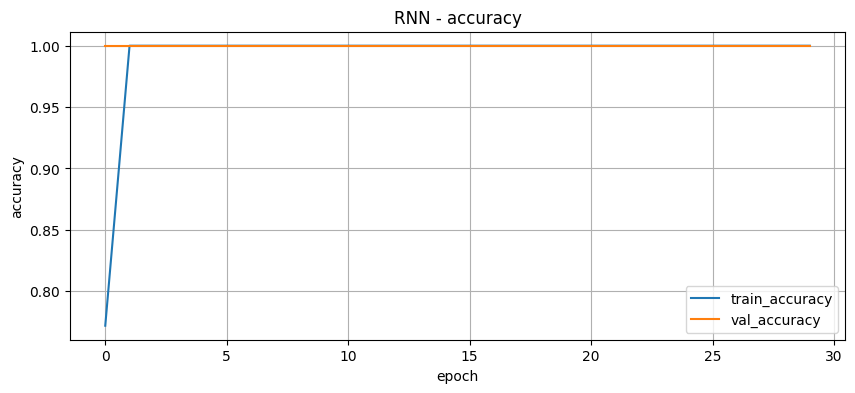

In [21]:
# ============================================
# 10. 결과 시각화
# ============================================

# 학습 손실 그래프
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('RNN - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

plt.show()


# 학습 정확도 그래프
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('RNN - accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

plt.show()

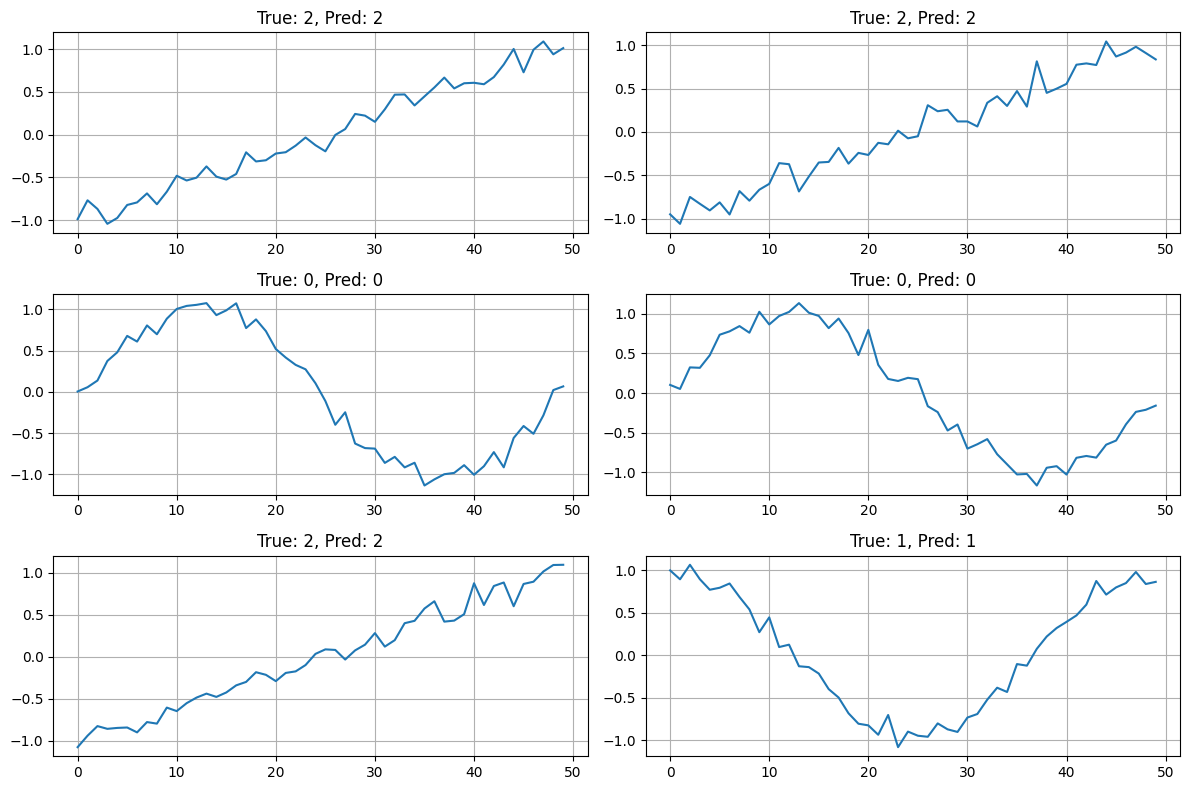

In [22]:
# 시퀀스패턴과 예측 결과 시각화
plt.figure(figsize=(12,8))
for i in range(6):
    plt.subplot(3,2,i+1)
    plt.plot(X_test[i].flatten())
    plt.title(f"True: {y_test[i]}, Pred: {y_pred[i]}")
    plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
! pip install LSTM